# Temporal Knowledge Graphs with Leakage Controls

**Chapter 23: Knowledge Graphs for Financial AI** | Section 23.6

**Docker image**: `ml4t`

> **Neo4j required**: This notebook queries a Neo4j graph database.
> Start Neo4j first, then run the notebook:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t python 23_knowledge_graphs/07_dynamic_kg_temporal.py
> ```


This notebook uses the real 8-K event graph loaded by `08_8k_event_extraction.py`
and demonstrates leakage-safe temporal KG analysis with explicit event,
public-disclosure, and extraction timestamps.

**Learning Objectives**:
- Build cutoff-safe temporal snapshots from a knowledge graph with three timestamps
- Compute relationship churn across consecutive snapshots as a dynamic feature
- Verify that post-cutoff events are excluded from the visible graph
- Understand the distinction between event time, disclosure time, and extraction time

**Book Reference**: Chapter 23, Section 23.6 (Temporal Integrity and Leakage-Safe Evaluation)

**Prerequisites**: Run `08_8k_event_extraction.py` first to populate Neo4j with timestamped events.

In [1]:
"""Temporal Knowledge Graphs with Leakage Controls - leakage-safe temporal KG analysis."""

from __future__ import annotations

import hashlib
import json
import os
from datetime import UTC, date, datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

from utils.paths import get_output_dir
from utils.style import COLORS, add_message_title, show_with_alt

In [2]:
WINDOW_DAYS = 90
CUTOFF_LAG_DAYS = 60

In [3]:
OUTPUT_DIR = get_output_dir(23, "dynamic_kg_temporal")
print(f"Output directory: {OUTPUT_DIR}")

NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

Output directory: 23_knowledge_graphs/output/dynamic_kg_temporal


## 1. Load the Real Temporal Event Graph

Query the event KG directly from Neo4j. Each relationship carries three dates:
the event date extracted from the filing text, the filing date when the
information became public, and the extraction date when the pipeline produced
the KG edge.

`GraphSnapshot` is not a label one notebook owns. `05_institutional_holdings_kg`
writes one for the 13F graph, and that node has no `extraction_time`. Neo4j sorts
null above every value, so `ORDER BY extraction_time DESC LIMIT 1` selects the 13F
snapshot whenever both notebooks have run against the same database, `WHERE
r.run_id = snapshot.run_id` then compares against a property that is not there,
and the query returns nothing. Not an error: an empty result, in the chapter's own
suggested order.

`08_8k_event_extraction` stamps its snapshot `snapshot_kind: '8k_events'`, so the
match names the producer instead of taking whichever node sorts first.

In [4]:
SNAPSHOT_KIND = "8k_events"

TEMPORAL_EVENT_QUERY = """
MATCH (snapshot:GraphSnapshot {snapshot_kind: $snapshot_kind})
WITH snapshot ORDER BY snapshot.extraction_time DESC LIMIT 1
MATCH (company:Company)-[r]->(target)
WHERE r.run_id = snapshot.run_id
  AND type(r) IN ['APPOINTED', 'ACQUIRED', 'ANNOUNCED', 'VALUED_AT']
  AND r.event_id IS NOT NULL
  AND r.event_time IS NOT NULL
  AND r.public_time IS NOT NULL
  AND r.extraction_time IS NOT NULL
RETURN r.event_id AS event_id,
       company.name AS subject,
       type(r) AS relation,
       coalesce(target.name, target.description, target.value_text) AS object,
       r.event_time AS event_time,
       r.public_time AS public_time,
       date(r.extraction_time) AS extraction_time,
       snapshot.run_id AS source_run_id,
       snapshot.source_sha256 AS source_sha256,
       snapshot.model AS extractor_model,
       snapshot.model_revision AS extractor_model_revision
ORDER BY public_time, subject, relation, object
"""

Convert Neo4j temporal values to ISO strings before Polars applies a strict
date schema.

In [5]:
def to_iso_date(value) -> str | None:
    """Convert a Neo4j temporal value to its ISO representation."""
    if value is None:
        return None
    return value.isoformat() if hasattr(value, "isoformat") else str(value)

Query the latest complete extractor snapshot and preserve its immutable
source and model identities on every returned edge.

In [6]:
def load_temporal_events() -> pl.DataFrame:
    """Load real temporal KG edges from Neo4j."""
    try:
        from neo4j import GraphDatabase
    except ImportError as exc:
        raise RuntimeError(
            "Neo4j support requires the `neo4j` Python driver. Install project dependencies first."
        ) from exc

    try:
        with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD)) as driver:
            driver.verify_connectivity()
            with driver.session() as session:
                available = session.run(
                    "MATCH (s:GraphSnapshot) RETURN coalesce(s.snapshot_kind, 'unlabelled') "
                    "AS kind, count(s) AS count ORDER BY kind"
                ).data()
                rows = [
                    record.data()
                    for record in session.run(TEMPORAL_EVENT_QUERY, snapshot_kind=SNAPSHOT_KIND)
                ]
    except Exception as exc:
        raise RuntimeError(
            f"Neo4j is required at {NEO4J_URI}. Run 08_8k_event_extraction.py first."
        ) from exc

    if not rows:
        raise RuntimeError(
            f"No {SNAPSHOT_KIND} snapshot with timestamped edges found in Neo4j. "
            f"Snapshots present: {available}. Run 08_8k_event_extraction.py first."
        )

    normalized_rows = [
        {
            **row,
            "event_time": to_iso_date(row["event_time"]),
            "public_time": to_iso_date(row["public_time"]),
            "extraction_time": to_iso_date(row["extraction_time"]),
        }
        for row in rows
    ]

    return pl.DataFrame(normalized_rows).with_columns(
        [
            pl.col("event_time").cast(pl.Date),
            pl.col("public_time").cast(pl.Date),
            pl.col("extraction_time").cast(pl.Date),
        ]
    )

In [7]:
events = load_temporal_events()
# display(), because a bare frame that is not the cell's last expression renders
# nothing and the two prints below it are.
display(events.head(10))
print(f"Temporal events loaded: {len(events)}")
print(f"Public date range: {events['public_time'].min()} to {events['public_time'].max()}")

event_id,subject,relation,object,event_time,public_time,extraction_time,source_run_id,source_sha256,extractor_model,extractor_model_revision
str,str,str,str,date,date,date,str,str,str,str
"""42fc5cb16df874c5c13f69c5""","""ADOBE INC.""","""ANNOUNCED""","""OFFERING OF NOTES""",2020-02-03,2020-02-03,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""
"""3833c6d68f06b9d7674cc2cf""","""RAYTHEON TECHNOLOGIES CORPORATION""","""ACQUIRED""","""SUBSIDIARY NOTES""",2020-06-10,2020-06-10,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""
"""0dff2bd0595c26a618659d03""","""RAYTHEON TECHNOLOGIES CORPORATION""","""ANNOUNCED""","""EXCHANGED SUBSIDIARY NOTES""",2020-05-11,2020-06-10,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""
"""631d8bbeb273e972f85e7060""","""RAYTHEON TECHNOLOGIES CORPORATION""","""VALUED_AT""","""8.19 BIL RTX NOTES""",2020-06-10,2020-06-10,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""
"""7ba6ad857e0d5a1baff4a075""","""FEDEX CORP""","""ANNOUNCED""","""ANNUAL MEETING""",2020-09-21,2020-09-22,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""
"""a6e5300a88f2962502db960e""","""PEPSICO INC""","""APPOINTED""","""DAVE LEWIS""",2020-11-13,2020-11-02,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""
"""4f655050ae42d648952a40f9""","""NVIDIA CORP""","""ANNOUNCED""","""FINANCIAL RESULTS""",2020-11-18,2020-11-18,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""
"""e5e2e2506881b4693abfe195""","""MEDTRONIC PLC""","""APPOINTED""","""NOT SPECIFIED""",2020-12-09,2020-12-14,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""
"""c9935040ea2f950f471d03cb""","""CHARTER COMMUNICATIONS, INC.""","""APPOINTED""","""JOHN BICKHAM""",2020-12-23,2020-12-28,2026-09-10,"""65fffbdab12c1a305c0dd701""","""260f95159ec6fddbfafdbcc919f28489c230564fa95ddb9297…","""Qwen/Qwen2.5-7B-Instruct""","""a09a35458c702b33eeacc393d103063234e8bc28"""


Temporal events loaded: 58
Public date range: 2020-02-03 to 2025-12-19


## 2. Lag Diagnostics

The event graph exposes the disclosure and extraction delays directly.

The disclosure lag is signed. An 8-K announcing an appointment effective next
month has an event date after its filing date, so its lag is negative, and
`post_disclosure_effective_date` counts those. An earlier version clamped the
negatives to zero before averaging while the figure histogrammed the unclamped
column, so the printed mean and the figure's mean were different numbers under
one name. Nothing is clamped now: a negative lag is a fact about the filing.

In [8]:
events = events.with_columns(
    [
        (pl.col("public_time") - pl.col("event_time")).dt.total_days().alias("disclosure_lag_days"),
        (pl.col("extraction_time") - pl.col("public_time"))
        .dt.total_days()
        .alias("extraction_lag_days"),
        (pl.col("subject") + "|" + pl.col("relation") + "|" + pl.col("object")).alias("triple"),
    ]
).with_columns((pl.col("disclosure_lag_days") < 0).alias("post_disclosure_effective_date"))

lag_summary = events.select(
    [
        pl.len().alias("events"),
        pl.col("subject").n_unique().alias("companies"),
        pl.col("relation").n_unique().alias("relation_types"),
        pl.col("post_disclosure_effective_date").sum().alias("future_effective_dates"),
        pl.col("disclosure_lag_days").mean().alias("avg_disclosure_lag_days"),
        pl.col("disclosure_lag_days").min().alias("min_disclosure_lag_days"),
        pl.col("disclosure_lag_days").max().alias("max_disclosure_lag_days"),
        pl.col("extraction_lag_days").mean().alias("avg_extraction_lag_days"),
    ]
)
print("Lag summary:")
print(lag_summary)

# An edge's identity is its event_id, which is what 08 merges on, so two filings
# reporting the same triple are two edges. The gap between the counts is how often
# that happens here.
if events["event_id"].n_unique() != events.height:
    raise RuntimeError("two edges share an event_id, so the graph key is not unique")
print(
    f"Edges: {events.height} events over {events['triple'].n_unique()} distinct "
    f"subject-relation-object triples"
)

Lag summary:
shape: (1, 8)
┌────────┬───────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ events ┆ companies ┆ relation_t ┆ future_eff ┆ avg_disclo ┆ min_disclo ┆ max_disclo ┆ avg_extrac │
│ ---    ┆ ---       ┆ ypes       ┆ ective_dat ┆ sure_lag_d ┆ sure_lag_d ┆ sure_lag_d ┆ tion_lag_d │
│ u32    ┆ u32       ┆ ---        ┆ es         ┆ ays        ┆ ays        ┆ ays        ┆ ays        │
│        ┆           ┆ u32        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│        ┆           ┆            ┆ u32        ┆ f64        ┆ i64        ┆ i64        ┆ f64        │
╞════════╪═══════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 58     ┆ 38        ┆ 4          ┆ 1          ┆ 7.155172   ┆ -11        ┆ 334        ┆ 1255.84482 │
│        ┆           ┆            ┆            ┆            ┆            ┆            ┆ 8          │
└────────┴───────────┴────────────┴────────────┴────────────┴───

### Temporal Event Distribution

Visualize when events occurred vs when they became publicly known.

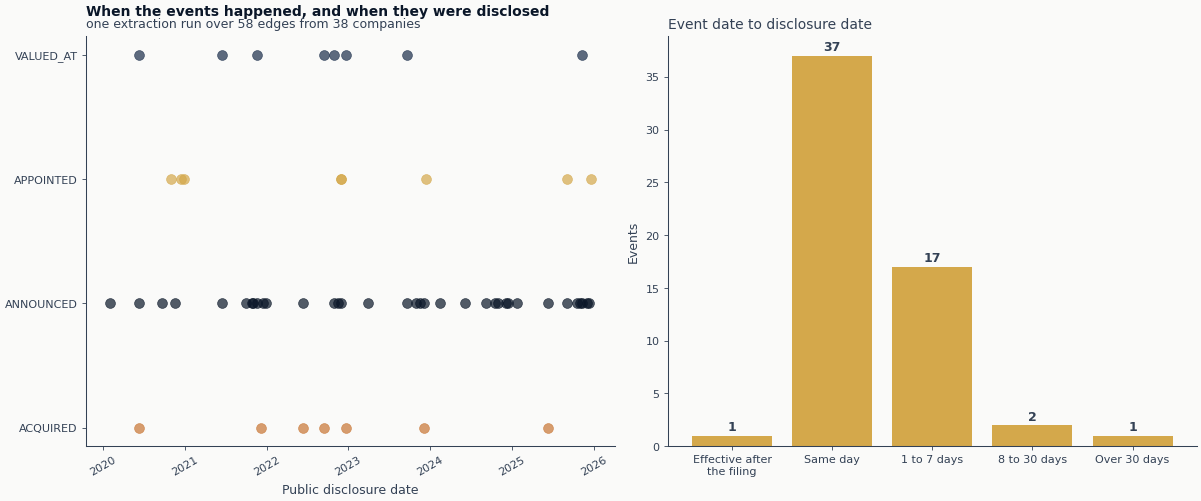

In [9]:
RELATION_COLORS = {
    "ANNOUNCED": COLORS["blue"],
    "APPOINTED": COLORS["amber"],
    "ACQUIRED": COLORS["copper"],
    "VALUED_AT": COLORS["slate"],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

# Panel (a): event timeline by relation type
relations = sorted(events["relation"].unique().to_list())
for rtype in relations:
    subset = events.filter(pl.col("relation") == rtype)
    axes[0].scatter(
        subset["public_time"].to_list(),
        [rtype] * subset.height,
        alpha=0.7,
        s=50,
        color=RELATION_COLORS.get(rtype, COLORS["silver_muted"]),
    )
axes[0].set_xlabel("Public disclosure date")
axes[0].set_title("Disclosures over time, by relation", loc="left")
axes[0].tick_params(axis="x", rotation=30)

# Panel (b): buckets, not a histogram. The mass sits on one value and a
# fixed-width bin hides it under a range set by a lone outlier.
LAG_BUCKETS = [
    ("Effective after\nthe filing", lambda lag: lag < 0),
    ("Same day", lambda lag: lag == 0),
    ("1 to 7 days", lambda lag: 1 <= lag <= 7),
    ("8 to 30 days", lambda lag: 8 <= lag <= 30),
    ("Over 30 days", lambda lag: lag > 30),
]
lags = events["disclosure_lag_days"].drop_nulls().to_list()
bucket_counts = [sum(1 for lag in lags if test(lag)) for _, test in LAG_BUCKETS]
if sum(bucket_counts) != len(lags):
    raise RuntimeError("the lag buckets do not partition the observed lags")
bars = axes[1].bar([label for label, _ in LAG_BUCKETS], bucket_counts, color=COLORS["amber"])
for bar, count in zip(bars, bucket_counts, strict=True):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(count),
        ha="center",
        fontweight="bold",
    )
axes[1].set_ylabel("Events")
axes[1].tick_params(axis="x", labelsize=8)
axes[1].set_title("Event date to disclosure date", loc="left")

add_message_title(
    axes[0],
    "When the events happened, and when they were disclosed",
    subtitle=(
        f"one extraction run over {events.height} edges from "
        f"{events['subject'].n_unique()} companies"
    ),
)
show_with_alt(
    fig,
    f"Two panels. The left scatter places {events.height} disclosures on a date axis, "
    f"one row per relation type, across {len(relations)} rows. The right bar chart "
    f"buckets the signed lag from event date to disclosure date: "
    + ", ".join(
        f"{count} {label.replace(chr(10), ' ').lower()}"
        for (label, _), count in zip(LAG_BUCKETS, bucket_counts, strict=True)
    )
    + ".",
)

Panel (a) places each disclosure on a date axis by relation type; panel (b) is
the signed lag from event date to disclosure date, the same column the summary
above averages. Mass to the left of zero is events whose effective date follows
the filing that announced them, which is why the lag is not clamped. Section 5
then measures how the visible graph grows across fixed windows, without assuming
this run represents the population of 8-K events.

## 3. Cutoff-Date Filtering

Build a point-in-time slice using public disclosure time rather than event time.

In [10]:
def visible_at_cutoff(df: pl.DataFrame, cutoff_date: date) -> pl.DataFrame:
    """Return only edges that were public by the cutoff date."""
    return df.filter(pl.col("public_time") <= cutoff_date)


latest_public = events["public_time"].max()
cutoff = latest_public - timedelta(days=CUTOFF_LAG_DAYS)
visible = visible_at_cutoff(events, cutoff)
hidden = events.filter(pl.col("public_time") > cutoff)

print(f"Cutoff date: {cutoff}")
print(f"Visible at cutoff: {len(visible)}")
print(f"Hidden after cutoff: {len(hidden)}")

Cutoff date: 2025-10-20
Visible at cutoff: 52
Hidden after cutoff: 6


## 4. Temporal Snapshots

Roll the public event stream into fixed windows so each snapshot respects the
same leakage guard.

In [11]:
def build_snapshots(df: pl.DataFrame, window_days: int) -> pl.DataFrame:
    """Aggregate temporal KG activity into fixed-width windows."""
    start = df["public_time"].min()
    end = df["public_time"].max()
    if start is None or end is None:
        return pl.DataFrame()

    rows = []
    window_start = start
    window = 0
    while window_start <= end:
        window_end = window_start + timedelta(days=window_days)
        window_df = df.filter(
            (pl.col("public_time") >= window_start) & (pl.col("public_time") < window_end)
        )
        rows.append(
            {
                "window": window,
                "start": window_start,
                "end": window_end,
                "n_edges": len(window_df),
                "n_subjects": window_df["subject"].n_unique() if len(window_df) else 0,
                "n_objects": window_df["object"].n_unique() if len(window_df) else 0,
                "n_relations": window_df["relation"].n_unique() if len(window_df) else 0,
            }
        )
        window += 1
        window_start = window_end

    return pl.DataFrame(rows)

In [12]:
snapshots = build_snapshots(visible, WINDOW_DAYS)
print("Snapshot summary:")
print(snapshots)

Snapshot summary:
shape: (24, 7)
┌────────┬────────────┬────────────┬─────────┬────────────┬───────────┬─────────────┐
│ window ┆ start      ┆ end        ┆ n_edges ┆ n_subjects ┆ n_objects ┆ n_relations │
│ ---    ┆ ---        ┆ ---        ┆ ---     ┆ ---        ┆ ---       ┆ ---         │
│ i64    ┆ date       ┆ date       ┆ i64     ┆ i64        ┆ i64       ┆ i64         │
╞════════╪════════════╪════════════╪═════════╪════════════╪═══════════╪═════════════╡
│ 0      ┆ 2020-02-03 ┆ 2020-05-03 ┆ 1       ┆ 1          ┆ 1         ┆ 1           │
│ 1      ┆ 2020-05-03 ┆ 2020-08-01 ┆ 3       ┆ 1          ┆ 3         ┆ 3           │
│ 2      ┆ 2020-08-01 ┆ 2020-10-30 ┆ 1       ┆ 1          ┆ 1         ┆ 1           │
│ 3      ┆ 2020-10-30 ┆ 2021-01-28 ┆ 4       ┆ 4          ┆ 4         ┆ 2           │
│ 4      ┆ 2021-01-28 ┆ 2021-04-28 ┆ 0       ┆ 0          ┆ 0         ┆ 0           │
│ 5      ┆ 2021-04-28 ┆ 2021-07-27 ┆ 2       ┆ 1          ┆ 2         ┆ 2           │
│ 6      ┆ 2021-07-27

## 5. Graph Growth Across Windows

Compare what the graph holds at the end of each window with what it held at the
end of the previous one.

The windows partition the events: each has one disclosure date, so it falls in
exactly one window. Comparing window contents to window contents therefore makes
every edge an addition and every previous edge a removal, their union is their
sum, and the ratio is one for every window of every input. An earlier version
reported that number as `relationship_churn`, and it was a property of the
partition rather than of the graph. It also keyed on the triple rather than the
event, which does not partition, so the constant it produced was not even the
constant its own construction implied.

The comparison that varies is between cumulative states: what a reader standing
at each window end can see. Removals are still zero, because a disclosure is not
retracted, and that is asserted rather than reported as if it might be otherwise.

In [13]:
def graph_growth(df: pl.DataFrame, window_days: int) -> pl.DataFrame:
    """Cumulative edge counts and per-window additions at each window end."""
    snapshots = build_snapshots(df, window_days)
    if snapshots.is_empty():
        return pl.DataFrame()

    rows = []
    previous_edges: set[str] = set()
    for row in snapshots.iter_rows(named=True):
        visible_so_far = df.filter(pl.col("public_time") < row["end"])
        current_edges = set(visible_so_far["event_id"].to_list())
        added = current_edges - previous_edges
        dropped = previous_edges - current_edges
        if dropped:
            raise RuntimeError(
                f"{len(dropped)} edges left the cumulative graph at window {row['window']}; "
                "a public disclosure is not retracted, so this cannot happen"
            )
        rows.append(
            {
                "window": row["window"],
                "start": row["start"],
                "window_edges": row["n_edges"],
                "cumulative_edges": len(current_edges),
                "cumulative_triples": visible_so_far["triple"].n_unique(),
                "added_edges": len(added),
                "growth_rate": len(added) / len(previous_edges) if previous_edges else None,
            }
        )
        previous_edges = current_edges

    return pl.DataFrame(rows)

In [14]:
growth = graph_growth(visible, WINDOW_DAYS)
print("Graph growth:")
print(growth)

Graph growth:
shape: (24, 7)
┌────────┬────────────┬──────────────┬────────────────┬────────────────┬─────────────┬─────────────┐
│ window ┆ start      ┆ window_edges ┆ cumulative_edg ┆ cumulative_tri ┆ added_edges ┆ growth_rate │
│ ---    ┆ ---        ┆ ---          ┆ es             ┆ ples           ┆ ---         ┆ ---         │
│ i64    ┆ date       ┆ i64          ┆ ---            ┆ ---            ┆ i64         ┆ f64         │
│        ┆            ┆              ┆ i64            ┆ i64            ┆             ┆             │
╞════════╪════════════╪══════════════╪════════════════╪════════════════╪═════════════╪═════════════╡
│ 0      ┆ 2020-02-03 ┆ 1            ┆ 1              ┆ 1              ┆ 1           ┆ null        │
│ 1      ┆ 2020-05-03 ┆ 3            ┆ 4              ┆ 4              ┆ 3           ┆ 3.0         │
│ 2      ┆ 2020-08-01 ┆ 1            ┆ 5              ┆ 5              ┆ 1           ┆ 0.25        │
│ 3      ┆ 2020-10-30 ┆ 4            ┆ 9              ┆ 9     

## 6. Leakage Tests

The obvious test is not a test. `visible` is the frame that `public_time <=
cutoff` produced, so asking whether it holds a row with `public_time > cutoff`
re-applies the negation of the predicate that built it. It returns zero for every
input, including an input where the cutoff logic is wrong, and printing it as
"Leakage test passed: True" says only that Polars filters correctly.

The three-timestamp model exists to expose a leakage the disclosure filter cannot
see. Every edge carries `extraction_time`, the date the pipeline produced it. An
edge is in this graph because one extraction run put it there, and that run
happened once, after all of it. So a reader standing at the cutoff could not have
had any of these edges, whatever their disclosure dates say. The second check
measures that, and on a single-run graph it fails by construction, which is the
point: it is the one thing a snapshot manifest and an extractor version cannot fix
on their own.

In [15]:
def disclosure_filter_postcondition(df: pl.DataFrame, cutoff_date: date) -> int:
    """Rows in the slice disclosed after the cutoff. Zero for every input, by construction."""
    return df.filter(pl.col("public_time") > cutoff_date).height


def edges_extracted_after(df: pl.DataFrame, cutoff_date: date) -> pl.DataFrame:
    """Visible edges the pipeline did not produce until after the cutoff."""
    return df.filter(pl.col("extraction_time") > cutoff_date)


postcondition_violations = disclosure_filter_postcondition(visible, cutoff)
if postcondition_violations:
    raise RuntimeError(
        f"{postcondition_violations} rows survived their own filter, which is impossible"
    )

late_extraction = edges_extracted_after(visible, cutoff)
late_share = late_extraction.height / visible.height if visible.height else 0.0
print(f"Disclosed after the cutoff and still visible: {postcondition_violations}")
print(
    f"Extracted after the cutoff and still visible: {late_extraction.height} of "
    f"{visible.height} ({late_share:.0%})"
)
if late_extraction.height:
    print(f"  earliest extraction: {late_extraction['extraction_time'].min()}, cutoff: {cutoff}")

Disclosed after the cutoff and still visible: 0
Extracted after the cutoff and still visible: 52 of 52 (100%)
  earliest extraction: 2026-09-10, cutoff: 2025-10-20


**Finding**: every visible edge was extracted after the cutoff, because this
graph comes from one extraction run and that run is more recent than any cutoff
it could be asked about. A backtest that reads this snapshot as of the cutoff is
using a graph that did not exist then, and no filter on disclosure time changes
that. Two things fix it, and both are pipeline properties rather than query
properties: run the extractor repeatedly and keep each run's edges under its own
extraction date, or refuse an edge until `extraction_time <= cutoff`, which on a
single-run graph leaves nothing to trade on and says so.

## 7. Persist Outputs

Alongside the parquet artifacts, write a `snapshot_manifest.json` recording
the cutoff, window, upstream extractor identity, and per-parquet SHA-256.
The manifest is the audit anchor for the §23.6 protocol bullet
*Log snapshot hash and extractor version*: it lets a reader reproduce the
exact visible-graph state and verify that downstream features were computed
from this snapshot.

In [16]:
def write_snapshot_manifest(
    out_dir: Path,
    cutoff_date: date,
    window_days: int,
    cutoff_lag_days: int,
    source_graph: dict[str, str],
    parquet_frames: dict[str, pl.DataFrame],
) -> Path:
    """Write snapshot_manifest.json with per-parquet row counts and SHA-256."""
    artifacts = {}
    for filename, df in parquet_frames.items():
        path = out_dir / filename
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        artifacts[filename] = {"rows": df.height, "sha256": digest}
    manifest = {
        "manifest_version": "1.0",
        "written_at": datetime.now(UTC).isoformat(timespec="seconds"),
        "cutoff_date": cutoff_date.isoformat(),
        "window_days": window_days,
        "cutoff_lag_days": cutoff_lag_days,
        "source_graph": source_graph,
        "artifacts": artifacts,
    }
    manifest_path = out_dir / "snapshot_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2))
    return manifest_path

In [17]:
events.write_parquet(OUTPUT_DIR / "temporal_events.parquet")
visible.write_parquet(OUTPUT_DIR / "visible_at_cutoff.parquet")
snapshots.write_parquet(OUTPUT_DIR / "temporal_snapshots.parquet")
growth.write_parquet(OUTPUT_DIR / "graph_growth.parquet")

source_run_ids = events["source_run_id"].unique().to_list()
if len(source_run_ids) != 1:
    raise RuntimeError(f"Expected one extractor run, found {source_run_ids}")

manifest_path = write_snapshot_manifest(
    out_dir=OUTPUT_DIR,
    cutoff_date=cutoff,
    window_days=WINDOW_DAYS,
    cutoff_lag_days=CUTOFF_LAG_DAYS,
    source_graph={
        "neo4j_uri": NEO4J_URI,
        "upstream_extractor": "08_8k_event_extraction.py",
        "upstream_run_id": source_run_ids[0],
        "source_sha256": events["source_sha256"].unique().item(),
        "extractor_model": events["extractor_model"].unique().item(),
        "extractor_model_revision": events["extractor_model_revision"].unique().item(),
    },
    parquet_frames={
        "temporal_events.parquet": events,
        "visible_at_cutoff.parquet": visible,
        "temporal_snapshots.parquet": snapshots,
        "graph_growth.parquet": growth,
    },
)

print(f"Saved: {OUTPUT_DIR / 'temporal_events.parquet'}")
print(f"Saved: {OUTPUT_DIR / 'visible_at_cutoff.parquet'}")
print(f"Saved: {OUTPUT_DIR / 'temporal_snapshots.parquet'}")
print(f"Saved: {OUTPUT_DIR / 'graph_growth.parquet'}")
print(f"Saved: {manifest_path}")

Saved: 23_knowledge_graphs/output/dynamic_kg_temporal/temporal_events.parquet
Saved: 23_knowledge_graphs/output/dynamic_kg_temporal/visible_at_cutoff.parquet
Saved: 23_knowledge_graphs/output/dynamic_kg_temporal/temporal_snapshots.parquet
Saved: 23_knowledge_graphs/output/dynamic_kg_temporal/graph_growth.parquet
Saved: 23_knowledge_graphs/output/dynamic_kg_temporal/snapshot_manifest.json


## 8. Verification

In [18]:
print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 70)
print(f"Temporal events: {len(events)}")
print(f"Visible at cutoff: {len(visible)}")
print(f"Hidden after cutoff: {len(hidden)}")
print(f"Cutoff date: {cutoff}")
print(f"Future effective dates: {lag_summary['future_effective_dates'][0]}")
print(f"Average disclosure lag (days): {lag_summary['avg_disclosure_lag_days'][0]:.1f}")
print(f"Average extraction lag (days): {lag_summary['avg_extraction_lag_days'][0]:.1f}")
print(f"Disclosed after the cutoff and still visible: {postcondition_violations}")
print(f"Extracted after the cutoff and still visible: {late_extraction.height} of {visible.height}")


NOTEBOOK EXECUTION COMPLETE
Temporal events: 58
Visible at cutoff: 52
Hidden after cutoff: 6
Cutoff date: 2025-10-20
Future effective dates: 1
Average disclosure lag (days): 7.2
Average extraction lag (days): 1255.8
Disclosed after the cutoff and still visible: 0
Extracted after the cutoff and still visible: 52 of 52


## Key Takeaways

1. **Three timestamps, three different questions.** The event date says when
   something happened, the disclosure date when a reader could have known, and
   the extraction date when this pipeline produced the edge. A cutoff applied to
   the first is lookahead; applied to the second it is point-in-time retrieval;
   the third is the one that says whether the graph itself existed yet.
2. **A test that re-applies its own filter cannot fail.** Asking whether a frame
   built by `public_time <= cutoff` contains a row with `public_time > cutoff`
   returns zero for every input, including inputs where the cutoff is wrong. It
   is a postcondition, and naming it a leakage test is what made a graph none of
   which existed at the cutoff report as leakage-free.
3. **Extraction time is the leakage this graph actually has.** Every visible edge
   was produced by a run more recent than any cutoff it can be asked about, so a
   backtest reading this snapshot is reading a graph that did not exist then.
   Fixing it is a pipeline change, not a query change.
4. **Disjoint windows make a churn metric constant.** Every disclosure falls in
   exactly one window, so window-to-window additions and removals sum to their
   union and the ratio is one for every window of every input. Comparing
   cumulative states instead measures something that varies.

5. **A snapshot manifest records identity, not sufficiency.** The cutoff, the
   window, the upstream run and the per-artifact hashes make this state
   reproducible. They do not make it tradable, and the extraction-time check
   above is what separates the two.

**Next**: See `09_knowledge_graph_features.py` for converting graph structure
into ML-ready features, and Chapter 23.6 for the full temporal integrity
framework.